# Imports

In [12]:
import numpy as np
import pandas as pd
from pandas import DataFrame
from pandas import concat
import matplotlib.pyplot as plt
from math import sqrt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

from DataHandler import DataLoader

In [3]:
DataLoader.hola()

hola


# Load Data

In [13]:
data = pd.read_excel("amerigo.xlsx")

In [10]:
data.head()

,Data,Ora Solare,Data + Ora Solare,fDOM Orario(QSU),Turbidity [FNU],Temp YSI [°C],DOC formula,Portate Fitterizzi [mc/s],Livel Idro Fit [m],Pioggia Fit [mm],Temp Fit [C°],Umidità Fit [%],Pres Atm Fit [hPa],Rad Solare Fit [W/mq],Vel Vento Fit
0,43607.0,0.750000,43607.750000,13.260000,13.571667,16.498333,1.496750,0.056543,0.38,0.0,19.8,NaN,994.3,202.0,7.1
1,43607.0,0.791667,43607.791667,13.933333,12.643333,15.787667,1.524671,0.056543,0.38,0.0,18.0,NaN,994.6,0.0,8.6
2,43607.0,0.833333,43607.833333,14.605000,12.095000,15.097667,1.553181,0.056543,0.38,0.0,17.2,NaN,994.9,0.0,6.2
3,43607.0,0.875000,43607.875000,14.641667,12.635000,14.543667,1.552910,0.039208,0.36,0.0,15.3,NaN,995.4,0.0,2.5
4,43607.0,0.916667,43607.916667,14.815000,13.243333,13.990333,1.559872,0.047201,0.37,0.0,11.5,NaN,995.6,0.0,2.8


In [6]:
data.isna().sum()

Data                            1
Ora Solare                      1
Data + Ora Solare               1
fDOM Orario(QSU)                1
Turbidity [FNU]                 1
Temp YSI [°C]                   1
DOC formula                     1
Portate Fitterizzi [mc/s]       1
Livel Idro Fit [m]             45
Pioggia Fit [mm]                1
Temp Fit [C°]                 113
Umidità Fit [%]              1753
Pres Atm Fit [hPa]             47
Rad Solare Fit  [W/mq]         26
Vel Vento Fit                1507
dtype: int64

In [7]:
data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Data,11567.0,44114.222097,331.918916,43607.000000,43728.000000,44272.000000,44393.000000,44526.000000
Ora Solare,11567.0,0.479356,0.288603,0.000000,0.208333,0.500000,0.750000,0.958333
Data + Ora Solare,11567.0,44114.701453,331.919074,43607.750000,43728.229167,44272.750000,44393.229167,44526.000000
fDOM Orario(QSU),11567.0,17.420886,6.218767,-3.843333,13.033333,17.645000,21.256667,48.988333
Turbidity [FNU],11567.0,42.961755,200.417240,0.951667,4.369167,7.555000,18.619167,4599.815000
Temp YSI [°C],11567.0,16.633281,4.520188,6.020333,13.150667,16.812000,20.179667,26.725500
DOC formula,11567.0,1.918567,1.186600,0.602878,1.492337,1.764329,1.958425,30.404323
Portate Fitterizzi [mc/s],11567.0,0.113600,0.284342,0.002397,0.017754,0.033998,0.097226,6.795935
Livel Idro Fit [m],11523.0,0.300569,0.083913,0.130000,0.240000,0.310000,0.340000,1.650000
Pioggia Fit [mm],11567.0,0.096654,0.679577,0.000000,0.000000,0.000000,0.000000,32.600000


In [14]:
last_gap_data = data[data["Data"] >= 44212].copy()

In [15]:
def f(data, start, end):
    return data[(data["Data"] > start) & (data["Data"] < end)]

# data[(data["Data"] > 44200) & (data["Data"] < 44215)]
f(data, 44200, 44215)

,Data,Ora Solare,Data + Ora Solare,fDOM Orario(QSU),Turbidity [FNU],Temp YSI [°C],DOC formula,Portate Fitterizzi [mc/s],Livel Idro Fit [m],Pioggia Fit [mm],Temp Fit [C°],Umidità Fit [%],Pres Atm Fit [hPa],Rad Solare Fit [W/mq],Vel Vento Fit
4338,44212.0,0.541667,44212.541667,8.818333,47.281667,8.924667,1.295652,0.239353,0.35,0.0,6.5,59.0,993.4,169.0,3.7
4339,44212.0,0.583333,44212.583333,8.540000,43.475000,9.071000,1.273351,0.309900,0.37,0.0,7.0,54.0,993.4,173.0,3.5
4340,44212.0,0.625000,44212.625000,14.341667,40.030000,9.034667,1.583799,0.272841,0.36,0.0,5.8,58.0,994.0,114.0,4.5
4341,44212.0,0.666667,44212.666667,41.310000,41.918333,8.950667,3.073139,0.209180,0.34,0.0,7.1,51.0,994.3,165.0,2.3
4342,44212.0,0.708333,44212.708333,40.290000,50.010000,8.679167,3.084598,0.239353,0.35,0.0,3.4,73.0,994.9,0.0,2.5
4343,44212.0,0.750000,44212.750000,38.756667,60.330000,8.291167,3.082656,0.239353,0.35,0.0,1.2,84.0,995.6,0.0,2.2
4344,44212.0,0.791667,44212.791667,41.738333,32.421667,7.942667,2.992060,0.239353,0.35,0.0,0.4,87.0,996.1,0.0,2.0
4345,44212.0,0.833333,44212.833333,41.150000,30.208333,7.692667,2.937547,0.239353,0.35,0.0,-0.1,89.0,996.6,0.0,3.0
4346,44212.0,0.875000,44212.875000,40.625000,27.618333,7.502333,2.885143,0.209180,0.34,0.0,-0.4,91.0,996.9,0.0,2.2
4347,44212.0,0.916667,44212.916667,40.850000,23.116667,7.348167,2.856577,0.182076,0.33,0.0,-0.8,90.0,997.3,0.0,2.5


In [235]:
last_gap_data.isna().sum()

Data                          0
Ora Solare                    0
Data + Ora Solare             0
fDOM Orario(QSU)              0
Turbidity [FNU]               0
Temp YSI [°C]                 0
DOC formula                   0
Portate Fitterizzi [mc/s]     0
Livel Idro Fit [m]           44
Pioggia Fit [mm]              0
Temp Fit [C°]                64
Umidità Fit [%]              65
Pres Atm Fit [hPa]           35
Rad Solare Fit  [W/mq]       22
Vel Vento Fit                16
dtype: int64

In [16]:
last_gap_data = last_gap_data.dropna()

In [237]:
last_gap_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Data,7101.0,44365.574989,88.651171,44212.000000,44289.000000,44364.000000,44438.000000,44526.000000
Ora Solare,7101.0,0.479193,0.289323,0.000000,0.208333,0.500000,0.750000,0.958333
Data + Ora Solare,7101.0,44366.054183,88.651740,44212.541667,44289.916667,44364.958333,44438.916667,44526.000000
fDOM Orario(QSU),7101.0,15.810895,6.527817,-3.843333,10.281667,15.136667,19.726667,48.988333
Turbidity [FNU],7101.0,36.901361,168.980892,0.951667,3.098333,5.230000,12.155000,2984.770000
Temp YSI [°C],7101.0,15.531898,4.744486,6.020333,11.394500,15.268500,19.448667,26.725500
DOC formula,7101.0,1.798544,1.164332,0.602878,1.330238,1.642324,1.853620,30.404323
Portate Fitterizzi [mc/s],7101.0,0.153091,0.334559,0.002397,0.022274,0.060111,0.136157,6.795935
Livel Idro Fit [m],7101.0,0.274994,0.093449,0.130000,0.210000,0.260000,0.310000,1.650000
Pioggia Fit [mm],7101.0,0.103732,0.638046,0.000000,0.000000,0.000000,0.000000,18.000000


In [17]:
d = last_gap_data.iloc[0]["Data"]
dd = last_gap_data.iloc[-1]["Data"]
print(d)
import datetime
print(pd.to_datetime(int(d), utc=True, unit='ms'))
print(pd.to_datetime(int(dd), utc=True, unit='ms'))

44212.0
1970-01-01 00:00:44.212000+00:00
1970-01-01 00:00:44.526000+00:00


In [23]:
corr = last_gap_data.corr()
# corr.style.background_gradient(cmap='coolwarm')
type(corr)

pandas.core.frame.DataFrame

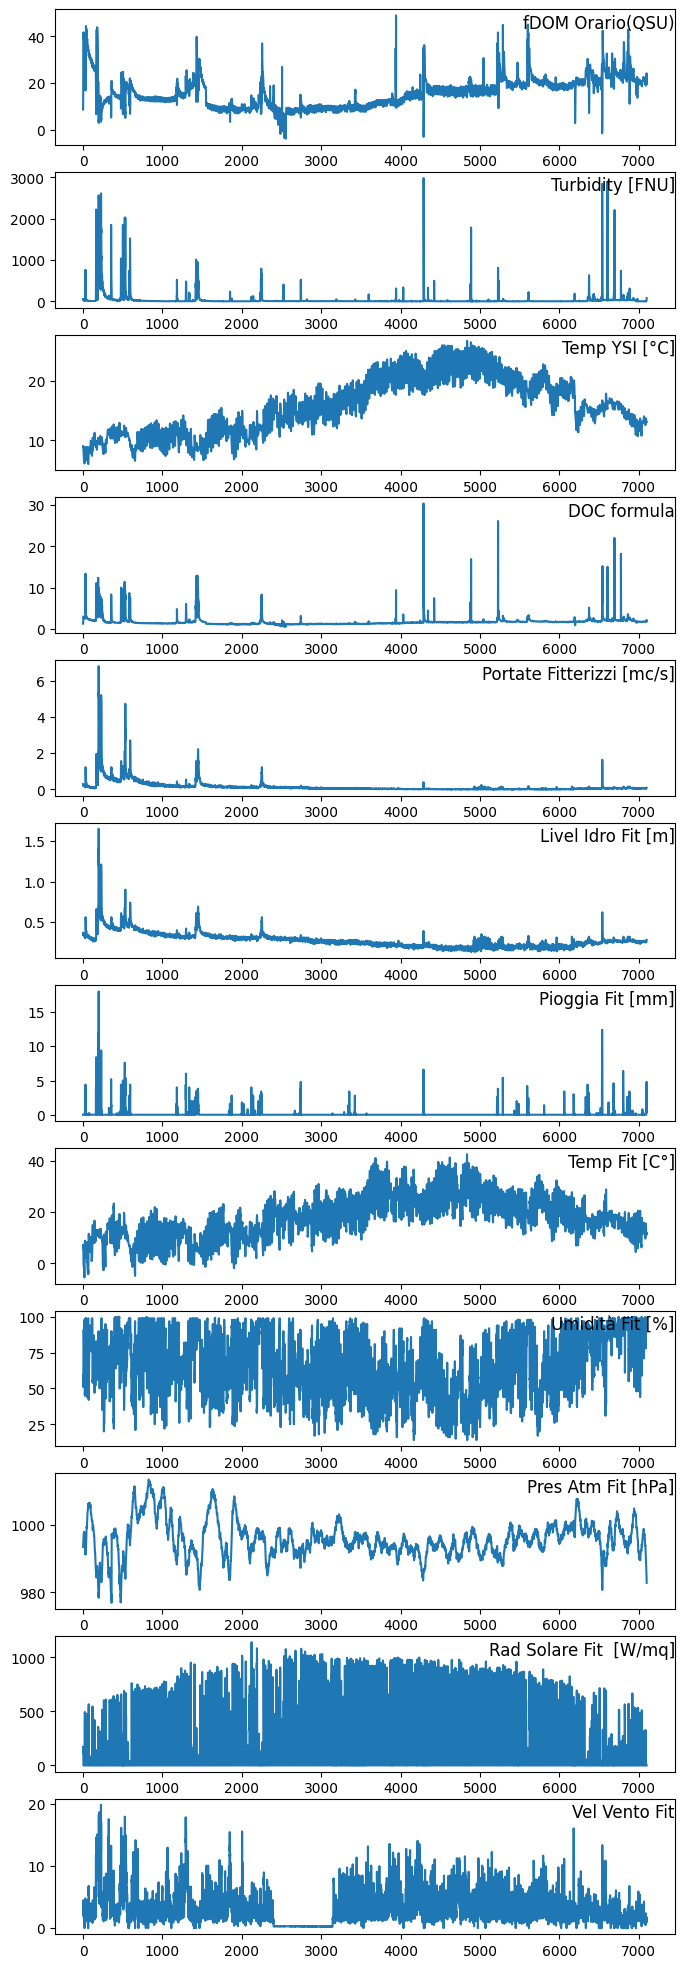

In [116]:
values = last_gap_data.values
groups = range(3,15)
i = 1
plt.figure(figsize=(8,25))
for group in groups:
    plt.subplot(len(groups), 1, i)
    plt.plot(values[:, group])
    plt.title(data.columns[group], y=0.8, loc='right')
    i += 1
plt.show()

# Data Preparation

In [26]:
# convert series to supervised learning
def series_to_supervised(data, n_in=1, n_out=1, dropnan=True):
    n_vars = 1 if type(data) is list else data.shape[1]
    df = DataFrame(data)
    cols, names = list(), list()
    # input sequence (t-n, ... t-1)
    for i in range(n_in, 0, -1):
        cols.append(df.shift(i))
        names += [('var%d(t-%d)' % (j+1, i)) for j in range(n_vars)]
    # forecast sequence (t, t+1, ... t+n)
    for i in range(0, n_out):
        cols.append(df.shift(-i))
        if i == 0:
            names += [('var%d(t)' % (j+1)) for j in range(n_vars)]
        else:
            names += [('var%d(t+%d)' % (j+1, i)) for j in range(n_vars)]
    # put it all together
    agg = concat(cols, axis=1)
    agg.columns = names
    # drop rows with NaN values
    if dropnan:
        agg.dropna(inplace=True)
    return agg

In [118]:
last_gap_data.columns

Index(['Data', 'Ora Solare', 'Data + Ora Solare', 'fDOM Orario(QSU)',
       'Turbidity [FNU]', 'Temp YSI [°C]', 'DOC formula',
       'Portate Fitterizzi [mc/s]', 'Livel Idro Fit [m]', 'Pioggia Fit [mm]',
       'Temp Fit [C°]', 'Umidità Fit [%]', 'Pres Atm Fit [hPa]',
       'Rad Solare Fit  [W/mq]', 'Vel Vento Fit'],
      dtype='object')

In [18]:
columns = ['Data',
 'fDOM Orario(QSU)',
 'Turbidity [FNU]',
 'Temp YSI [°C]',
 'DOC formula',
 'Portate Fitterizzi [mc/s]',
 'Livel Idro Fit [m]',
 'Pioggia Fit [mm]',
 'Temp Fit [C°]',
 'Umidità Fit [%]',
 'Pres Atm Fit [hPa]',
 'Rad Solare Fit  [W/mq]',
 'Vel Vento Fit']

In [19]:
last_gap_data = last_gap_data[columns]

In [20]:
last_gap_data.values

array([[4.42120000e+04, 8.81833333e+00, 4.72816667e+01, ...,
        9.93400000e+02, 1.69000000e+02, 3.70000000e+00],
       [4.42120000e+04, 8.54000000e+00, 4.34750000e+01, ...,
        9.93400000e+02, 1.73000000e+02, 3.50000000e+00],
       [4.42120000e+04, 1.43416667e+01, 4.00300000e+01, ...,
        9.94000000e+02, 1.14000000e+02, 4.50000000e+00],
       ...,
       [4.45250000e+04, 2.26066667e+01, 1.10550000e+01, ...,
        9.84700000e+02, 0.00000000e+00, 1.60000000e+00],
       [4.45250000e+04, 2.41816667e+01, 5.47250000e+01, ...,
        9.84500000e+02, 0.00000000e+00, 1.40000000e+00],
       [4.45260000e+04, 1.95016667e+01, 7.89566667e+01, ...,
        9.82800000e+02, 0.00000000e+00, 1.70000000e+00]])

In [21]:
last_gap_data

,Data,fDOM Orario(QSU),Turbidity [FNU],Temp YSI [°C],DOC formula,Portate Fitterizzi [mc/s],Livel Idro Fit [m],Pioggia Fit [mm],Temp Fit [C°],Umidità Fit [%],Pres Atm Fit [hPa],Rad Solare Fit [W/mq],Vel Vento Fit
4338,44212.0,8.818333,47.281667,8.924667,1.295652,0.239353,0.35,0.0,6.5,59.0,993.4,169.0,3.7
4339,44212.0,8.540000,43.475000,9.071000,1.273351,0.309900,0.37,0.0,7.0,54.0,993.4,173.0,3.5
4340,44212.0,14.341667,40.030000,9.034667,1.583799,0.272841,0.36,0.0,5.8,58.0,994.0,114.0,4.5
4341,44212.0,41.310000,41.918333,8.950667,3.073139,0.209180,0.34,0.0,7.1,51.0,994.3,165.0,2.3
4342,44212.0,40.290000,50.010000,8.679167,3.084598,0.239353,0.35,0.0,3.4,73.0,994.9,0.0,2.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11563,44525.0,20.085000,2.061667,13.067500,1.776992,0.060111,0.26,0.0,11.2,97.0,986.8,0.0,1.2
11564,44525.0,20.556667,3.593333,13.057333,1.805989,0.060111,0.26,1.6,11.6,98.0,985.8,0.0,0.9
11565,44525.0,22.606667,11.055000,13.061167,1.939867,0.071638,0.27,1.0,12.0,99.0,984.7,0.0,1.6
11566,44525.0,24.181667,54.725000,13.078333,2.252222,0.084833,0.28,4.8,12.0,99.0,984.5,0.0,1.4


In [22]:
values = last_gap_data.values
scaler = MinMaxScaler(feature_range=(0, 1))
scaled = scaler.fit_transform(values)

In [23]:
reframed = series_to_supervised(scaled, 4, 1)

NameError: name 'series_to_supervised' is not defined

In [189]:
n_features = 13

In [82]:
reframed.columns

Index(['var1(t-4)', 'var2(t-4)', 'var3(t-4)', 'var4(t-4)', 'var5(t-4)',
       'var6(t-4)', 'var7(t-4)', 'var8(t-4)', 'var9(t-4)', 'var10(t-4)',
       'var11(t-4)', 'var12(t-4)', 'var13(t-4)', 'var14(t-4)', 'var15(t-4)',
       'var1(t-3)', 'var2(t-3)', 'var3(t-3)', 'var4(t-3)', 'var5(t-3)',
       'var6(t-3)', 'var7(t-3)', 'var8(t-3)', 'var9(t-3)', 'var10(t-3)',
       'var11(t-3)', 'var12(t-3)', 'var13(t-3)', 'var14(t-3)', 'var15(t-3)',
       'var1(t-2)', 'var2(t-2)', 'var3(t-2)', 'var4(t-2)', 'var5(t-2)',
       'var6(t-2)', 'var7(t-2)', 'var8(t-2)', 'var9(t-2)', 'var10(t-2)',
       'var11(t-2)', 'var12(t-2)', 'var13(t-2)', 'var14(t-2)', 'var15(t-2)',
       'var1(t-1)', 'var2(t-1)', 'var3(t-1)', 'var4(t-1)', 'var5(t-1)',
       'var6(t-1)', 'var7(t-1)', 'var8(t-1)', 'var9(t-1)', 'var10(t-1)',
       'var11(t-1)', 'var12(t-1)', 'var13(t-1)', 'var14(t-1)', 'var15(t-1)',
       'var1(t)', 'var2(t)', 'var3(t)', 'var4(t)', 'var5(t)', 'var6(t)',
       'var7(t)', 'var8(t)', 'var9(t)',

In [37]:
reframed

In [38]:
reframed.drop(reframed.columns[[13,14,15,16,18,19,20,21,22,23,24,25]], axis=1, inplace=True)
print(reframed.columns)

Index(['var1(t-1)', 'var2(t-1)', 'var3(t-1)', 'var4(t-1)', 'var5(t-1)',
       'var6(t-1)', 'var7(t-1)', 'var8(t-1)', 'var9(t-1)', 'var10(t-1)',
       'var11(t-1)', 'var12(t-1)', 'var13(t-1)', 'var3(t)', 'var12(t)',
       'var13(t)', 'var14(t)', 'var15(t)'],
      dtype='object')


In [198]:
...
# split into train and test sets
values = reframed.values
n_train_hours = 5000
train = values[:n_train_hours, :]
test = values[n_train_hours:, :]
# split into input and outputs
train_X, train_y = train[:, :-1], train[:, -1]
test_X, test_y = test[:, :-1], test[:, -1]
# reshape input to be 3D [samples, timesteps, features]
train_X = train_X.reshape((train_X.shape[0], 1, train_X.shape[1]))
test_X = test_X.reshape((test_X.shape[0], 1, test_X.shape[1]))
print(train_X.shape, train_y.shape, test_X.shape, test_y.shape)

(5000, 1, 13) (5000,) (2100, 1, 13) (2100,)


# Model

/home/luis/.local/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


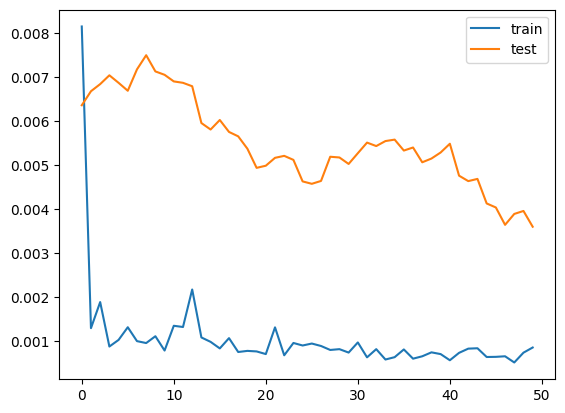

In [210]:
# create and fit the LSTM network
model = Sequential()
model.add(LSTM(50, input_shape=(1, look_back)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
history = model.fit(train_X, train_y, epochs=50, batch_size=72, validation_data=(test_X, test_y), verbose=0, shuffle=False)
# plot history
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

In [218]:
...
# make a prediction
yhat = model.predict(test_X)
test_X = test_X.reshape((test_X.shape[0], test_X.shape[1]))
# invert scaling for forecast
inv_yhat = np.concatenate((yhat, test_X[:, 1:]), axis=1)
inv_yhat = scaler.inverse_transform(inv_yhat)
inv_yhat = inv_yhat[:,0]
# invert scaling for actual
test_y = test_y.reshape((len(test_y), 1))
inv_y = np.concatenate((test_y, test_X[:, 1:]), axis=1)
inv_y = scaler.inverse_transform(inv_y)
inv_y = inv_y[:,0]
# calculate RMSE
rmse = sqrt(mean_squared_error(inv_y, inv_yhat))
print('Test RMSE: %.3f' % rmse)

66/66 ━━━━━━━━━━━━━━━━━━━━ 0s 567us/step
Test RMSE: 18.844


In [214]:
test_X.shape

(2100, 13)